/data/gravwav/koley/my_venv/lib/python3.10/site-packages/obspy/io/stationxml/core.py:91: UserWarning: The StationXML file has version 1.2, ObsPy can read versions (1.0, 1.1). Proceed with caution.
  warnings.warn("The StationXML file has version %s, ObsPy can "


[OBSN_BHZ] chunk 1/12: owner=[0.0,7200.0) read=[0.0,11400.0)
read start UTC 2026-02-10T00:00:00.000000Z
[OBSN_BHZ] chunk 2/12: owner=[7200.0,14400.0) read=[6600.0,18600.0)
read start UTC 2026-02-10T01:50:00.000000Z
[OBSN_BHZ] chunk 3/12: owner=[14400.0,21600.0) read=[13800.0,25800.0)
read start UTC 2026-02-10T03:50:00.000000Z
[OBSN_BHZ] chunk 4/12: owner=[21600.0,28800.0) read=[21000.0,33000.0)
read start UTC 2026-02-10T05:50:00.000000Z
[OBSN_BHZ] chunk 5/12: owner=[28800.0,36000.0) read=[28200.0,40200.0)
read start UTC 2026-02-10T07:50:00.000000Z
[OBSN_BHZ] chunk 6/12: owner=[36000.0,43200.0) read=[35400.0,47400.0)
read start UTC 2026-02-10T09:50:00.000000Z
[OBSN_BHZ] chunk 7/12: owner=[43200.0,50400.0) read=[42600.0,54600.0)
read start UTC 2026-02-10T11:50:00.000000Z
[OBSN_BHZ] chunk 8/12: owner=[50400.0,57600.0) read=[49800.0,61800.0)
read start UTC 2026-02-10T13:50:00.000000Z
[OBSN_BHZ] chunk 9/12: owner=[57600.0,64800.0) read=[57000.0,69000.0)
read start UTC 2026-02-10T15:50:00.00

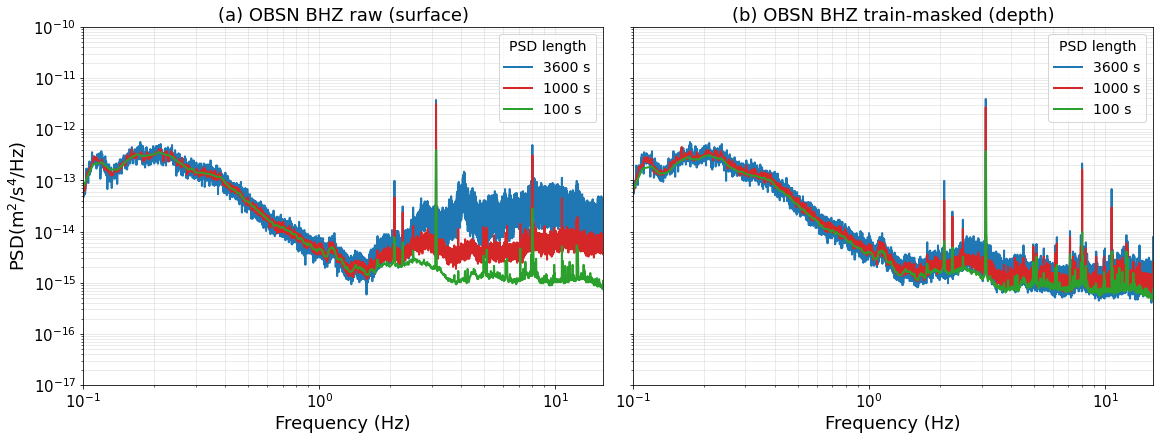

In [1]:
import os
import re
import math
import pickle
import datetime
import numpy as np
import scipy.signal as sp
import matplotlib.pyplot as plt

from obspy import read_inventory, UTCDateTime
from obspy.clients.filesystem.sds import Client
from modules import trainMaskMod

# ============================================================
# User configuration
# ============================================================
rootP2 = '/dcache/etseis/et/EMR/Data'
archiveP2 = Client(rootP2)
stnName = 'OBSN'
compName = 'BHZ'

inventoryFiles = {
    stnName: '/dcache/etseis/et/EMR/Stations/Stations/NL.'+ stnName + '.xml'}

inventories = {sta: read_inventory(path) for sta, path in inventoryFiles.items()}

preFiltDefault = [0.05, 0.1, 16, 18]

dateStVec = np.array([41])
yearVec = np.array([2026])
nDays = 1

# units in seconds
psdLengths = [3600, 1000, 100]
chunkOwnerSec = 7200
responsePadSec = 600

# histogram settings for PSDs in log10(PSD)
logPsdMin = -24
logPsdMax = -8
nHistBinsPsd = 800
histEdgesPsd = np.linspace(logPsdMin, logPsdMax, nHistBinsPsd + 1)

# histogram settings for attenuation in dB
attDbMin = -80
attDbMax = 40
nHistBinsAtt = 800
histEdgesAtt = np.linspace(attDbMin, attDbMax, nHistBinsAtt + 1)

#outputDir = '/data/gravwav/koley/PSDHistBoreholes/PSDLenTrainRemove/'
#os.makedirs(outputDir, exist_ok=True)

pairConfigs = [
    {
        "label": stnName + '_' + compName,
        "ch0": {
            "station": stnName,
            "network": "NL",
            "location": "00",
            "channel": compName,
            "inventory_key": stnName,
            "use_prefilt": True,
            "pre_filt": preFiltDefault,
            "output_unit": "VEL",
        },
        "ch1": {
            "station": stnName,
            "network": "NL",
            "location": "01",
            "channel": compName,
            "inventory_key": stnName,
            "use_prefilt": True,
            "pre_filt": preFiltDefault,
            "output_unit": "VEL",
        },
        "depth_diff_m": 300.0,
    },
]


# ============================================================
# Train detector parameters
# ============================================================
trainParams = {
    "spec_win_sec": 20.0,
    "spec_overlap_frac": 0.5,
    "f_band": (6.0, 15.0),
    "z_thresh": 2,
    "min_duration_sec": 20.0,
    "pad_sec": 20.0,
    "mask_ramp_sec": 10.0,
}

# ============================================================
# Main
# ============================================================
day0 = int(dateStVec[0])
year0 = int(yearVec[0])
A = datetime.datetime(year0, 1, 1) + datetime.timedelta(days=day0 - 1)
dateUse = UTCDateTime(A.year, A.month, A.day)

savedFiles = []
for pairCfg in pairConfigs:
    outfile = trainMaskMod.processOnePair(archive=archiveP2, pairCfg=pairCfg, inventories=inventories, preFiltDefault=preFiltDefault, dateUse=dateUse,
                               nDays=nDays, psdLengths=psdLengths, chunkOwnerSec=chunkOwnerSec, responsePadSec=responsePadSec,
                               histEdgesPsd=histEdgesPsd, histEdgesAtt=histEdgesAtt, outputDir=outputDir,
                               trainParams=trainParams)
    if outfile is not None:
        savedFiles.append(outfile)

print("\nSaved files:")
for f in savedFiles:
    print(f)

for f in savedFiles:
    trainMaskMod.plotPairResults(f, titlePrefix=stnName + ' ' + compName)